# 1. Introduction

The purpose of this project is to demonstrate the implementation of a data integration pipeline using Apache Spark and the IMDb public dataset.

Three IMDb datasets containing movie metadata, ratings and director information are loaded, cleaned and integrated using the common identifier **`tconst`**. The resulting dataset is transformed and stored in Parquet format before being analysed using Spark SQL.

The project aims to answer the following business question:

How can movie metadata, ratings and crew information be integrated using Apache Spark to identify characteristics associated with highly rated films?

## Technologies Used
- Apache Spark / PySpark — distributed data processing
- Databricks Free Edition — cloud notebook environment
- Parquet — columnar storage format for the integrated dataset
- Spark SQL — analytical querying
- Matplotlib & Pandas — data visualisation
- Python 3

## Pipeline Overview
1. Data Loading — load three IMDb TSV files into Spark DataFrames
2. Data Cleaning — filter, remove nulls, drop columns, cast data types
3. Data Integration — join all three datasets using the common key tconst
4. Save to Parquet — persist the integrated dataset in columnar format
5. Genre Normalisation — explode genres for genre-level analysis
6. Spark SQL Analysis — five analytical queries answering the business question
7. Visualisations — five charts communicating key findings

#2. Data Loading



##  Loading the title basics dataset
- This file contains movie metadata: titles, release years, genres, and runtime.
- tconst is IMDb's unique identifier for each title and it's used as the key to connect all three datasets together.


In [0]:
df_basics = (
    spark.read
    .option("header", True)
    .option("sep", "\t")
    .csv("/Volumes/imdb_final_a/database/dataset_imdb/title.basics.tsv")
)

df_basics.printSchema()
df_basics.show(5)

root
 |-- tconst: string (nullable = true)
 |-- titleType: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- originalTitle: string (nullable = true)
 |-- isAdult: string (nullable = true)
 |-- startYear: string (nullable = true)
 |-- endYear: string (nullable = true)
 |-- runtimeMinutes: string (nullable = true)
 |-- genres: string (nullable = true)

+---------+---------+--------------------+--------------------+-------+---------+-------+--------------+--------------------+
|   tconst|titleType|        primaryTitle|       originalTitle|isAdult|startYear|endYear|runtimeMinutes|              genres|
+---------+---------+--------------------+--------------------+-------+---------+-------+--------------+--------------------+
|tt0000001|    short|          Carmencita|          Carmencita|      0|     1894|     \N|             1|   Documentary,Short|
|tt0000002|    short|Le clown et ses c...|Le clown et ses c...|      0|     1892|     \N|             5|     Animation,

## Loading the ratings dataset
- Contains the average rating and number of votes for each title.


In [0]:
# Contains one row per title with its average rating and number of user votes

df_ratings = (
    spark.read
    .option("header", True)
    .option("sep", "\t")
    .csv("/Volumes/imdb_final_a/database/dataset_imdb/title.ratings.tsv")
)
df_ratings.printSchema()
df_ratings.show(5)


root
 |-- tconst: string (nullable = true)
 |-- averageRating: string (nullable = true)
 |-- numVotes: string (nullable = true)

+---------+-------------+--------+
|   tconst|averageRating|numVotes|
+---------+-------------+--------+
|tt0000001|          5.7|    2211|
|tt0000002|          5.4|     319|
|tt0000003|          6.4|    2344|
|tt0000004|          5.1|     192|
|tt0000005|          6.2|    3061|
+---------+-------------+--------+
only showing top 5 rows


## Loading the crew dataset
- Contains the directors and writers for each title.


In [0]:

# Contains director and writer nm-codes for each title 

df_crew = (
    spark.read
    .option("header", True)
    .option("sep", "\t")
    .csv("/Volumes/imdb_final_a/database/dataset_imdb/title.crew.tsv")
)
df_crew.printSchema()
df_crew.show(5)

root
 |-- tconst: string (nullable = true)
 |-- directors: string (nullable = true)
 |-- writers: string (nullable = true)

+---------+---------+---------+
|   tconst|directors|  writers|
+---------+---------+---------+
|tt0000001|nm0005690|       \N|
|tt0000002|nm0721526|       \N|
|tt0000003|nm0721526|nm0721526|
|tt0000004|nm0721526|       \N|
|tt0000005|nm0005690|       \N|
+---------+---------+---------+
only showing top 5 rows


### Checking dataset sizes

In [0]:
print("Basics:", df_basics.count())
print("Ratings:", df_ratings.count())
print("Crew:", df_crew.count())

Basics: 12573116
Ratings: 1681110
Crew: 12566197


# 3. Data Cleaning



In [0]:
from pyspark.sql.functions import col, split, explode

### Filter Movies Only

In [0]:
# Keep only records where title type is movie
# Only keep movies because mixing movies, TV shows and episodes would make the analysis inconsistent and harder to interpret.

movies_df = df_basics.filter(df_basics.titleType == "movie")

print("Movies only:", movies_df.count())


Movies only: 749341


### Remove Unnecessary Columns for Analysis


In [0]:

movies_df = movies_df.select(
    "tconst",
    "primaryTitle",
    "startYear",
    "runtimeMinutes",
    "genres"
)
# Remove columns that are not required for analysis to reduc storage and improve processing efficiency.

movies_df.show(5)

+---------+--------------------+---------+--------------+--------------------+
|   tconst|        primaryTitle|startYear|runtimeMinutes|              genres|
+---------+--------------------+---------+--------------+--------------------+
|tt0000009|          Miss Jerry|     1894|            45|             Romance|
|tt0000147|The Corbett-Fitzs...|     1897|           100|Documentary,News,...|
|tt0000502|            Bohemios|     1905|           100|                  \N|
|tt0000574|The Story of the ...|     1906|            70|Action,Adventure,...|
|tt0000591|    The Prodigal Son|     1907|            90|               Drama|
+---------+--------------------+---------+--------------+--------------------+
only showing top 5 rows


### Remove missing values
- IMDb uses the string "\N" to represent missing values in TSV files.
- backlash is an escape character in Python = must be written as "\\N" so the code reads it as a literal text string.



In [0]:
# Remove missing startYear records

missing_years = movies_df.filter(col("startYear") == "\\N").count()
print("Records with missing startYear:", missing_years)

movies_df = movies_df.filter(col("startYear") != "\\N")
print("Rows after removing missing startYear:", movies_df.count())

Records with missing startYear: 112678
Rows after removing missing startYear: 636663


In [0]:
# Remove missing Genres records

missing_genres = movies_df.filter(col("genres") == "\\N").count()
print("Records with missing genre:", missing_genres)

movies_df = movies_df.filter(col("genres") != "\\N")
print("Rows after removing missing Genre:", movies_df.count())

Records with missing genre: 70834
Rows after removing missing Genre: 565829


In [0]:

# Remove missing runtimeMinutes records
missing_runtime = movies_df.filter(col("runtimeMinutes") == "\\N").count()
print("Records with missing runtimeMinutes:", missing_runtime)

movies_df = movies_df.filter(col("runtimeMinutes") != "\\N")
print("Rows after removing missing runtimeMinutes:", movies_df.count())

Records with missing runtimeMinutes: 127631
Rows after removing missing runtimeMinutes: 438198


### Convert Data Types
The raw TSV files load all columns as strings.
Convert columns to their correct data types for accurate analysis.

In [0]:
# startYear ->  string to integer
movies_df = movies_df.withColumn("startYear", col("startYear").cast("integer"))

# runtimeMinutes -> string to integer
movies_df = movies_df.withColumn("runtimeMinutes", col("runtimeMinutes").cast("integer"))

# Verify the updated schema.
movies_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- runtimeMinutes: integer (nullable = true)
 |-- genres: string (nullable = true)



### Clean Ratings Dataset

In [0]:
ratings_df = df_ratings.withColumn(
    "averageRating",
    col("averageRating").cast("double")
).withColumn(
    "numVotes",
    col("numVotes").cast("integer")
)

ratings_df.printSchema()


root
 |-- tconst: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)



### Clean Crew Dataset

In [0]:
# The writers column is dropped because this project focuses on director influence, including them would add complexity without directly answering the business question

crew_df = df_crew.select(
    "tconst",
    "directors"
)

crew_df = crew_df.filter(col("directors")!= "\\N")

### Cleaned Dataset Summary

In [0]:
print("Movies:", movies_df.count())
print("Ratings:", ratings_df.count())
print("Crew:", crew_df.count())

Movies: 438198
Ratings: 1681110
Crew: 7011312


In [0]:
movies_df.printSchema()
ratings_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- runtimeMinutes: integer (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- tconst: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)



# 4. Data Integration



In [0]:
# Join Movies + Ratings using tconst

movie_ratings_df = movies_df.join(
    ratings_df,
    on="tconst",
    how="inner"
)

print("Movie + Ratings rows:", movie_ratings_df.count())

Movie + Ratings rows: 304545


In [0]:
# Join Crew Information

integrated_df = movie_ratings_df.join(
    crew_df,
    on="tconst",
    how="inner"
)
print("Integrated Datasets Rows:", integrated_df.count())

Integrated Datasets Rows: 302308


In [0]:
# Check Structure
integrated_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- runtimeMinutes: integer (nullable = true)
 |-- genres: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)
 |-- directors: string (nullable = true)



In [0]:
# Preview Dataset

integrated_df.show(10, truncate=False)

+---------+--------------------------+---------+--------------+--------------------+-------------+--------+---------+
|tconst   |primaryTitle              |startYear|runtimeMinutes|genres              |averageRating|numVotes|directors|
+---------+--------------------------+---------+--------------+--------------------+-------------+--------+---------+
|tt0004134|Hypocrites                |1915     |54            |Drama,Fantasy       |6.4          |836     |nm0916665|
|tt0019478|Tillie's Punctured Romance|1928     |57            |Comedy              |6.5          |36      |nm0840042|
|tt0024099|O' Schwarzwald, O' Heimat |1933     |86            |Comedy              |6.1          |69      |nm0091380|
|tt0024374|En natt på Smygeholm      |1933     |80            |Comedy              |3.0          |23      |nm0909436|
|tt0027552|Bizarre, Bizarre          |1937     |84            |Comedy              |7.3          |2126    |nm0138893|
|tt0029814|La zandunga               |1938     |100     

### Data Quality Validation

In [0]:
print("Movie dataset:", movies_df.count() )
print("Ratings dataset:", ratings_df.count())
print("Crew dataset:", crew_df.count())
print("Integrated dataset:", integrated_df.count())

Movie dataset: 438198
Ratings dataset: 1681110
Crew dataset: 7011312
Integrated dataset: 302308


#5. Save to Parquet



### Save Integrated Dataset as Parquet


In [0]:

integrated_df.write \
    .mode("overwrite") \
    .parquet("/Volumes/imdb_final_a/database/dataset_imdb/imdb_parquet")

In [0]:
# Read the parquet file back into Spark

parquet_df = spark.read.parquet(
    "/Volumes/imdb_final_a/database/dataset_imdb/imdb_parquet"
)

print("Rows in parquet file:", parquet_df.count())
parquet_df.printSchema()
parquet_df.show(5, truncate=False)

Rows in parquet file: 302308
root
 |-- tconst: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- runtimeMinutes: integer (nullable = true)
 |-- genres: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)
 |-- directors: string (nullable = true)

+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+
|tconst   |primaryTitle                  |startYear|runtimeMinutes|genres                    |averageRating|numVotes|directors          |
+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+
|tt0000009|Miss Jerry                    |1894     |45            |Romance                   |5.3          |231     |nm0085156          |
|tt0000147|The Corbett-Fitzsimmons Fight |1897     |100           |Documentar

#6.  Genre Normalization 
In the integrated dataset, each movie's genres are stored as a single comma-separated string (e.g. `"Action,Adventure,Comedy"`).

To perform genre-level analysis — such as finding the average rating per genre — we need one row per genre per movie. This transformation is called **exploding** the genres column.

In [0]:
# Create a new DataFrame for genre analysis

genre_df = integrated_df.withColumn(
    "genre",
    explode(split(col("genres"), ",")) 
# The split() function converts the text into a list.
# The explode() function creates one row per genre.
)
genre_df.show(10, truncate=False)

+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+-----------+
|tconst   |primaryTitle                  |startYear|runtimeMinutes|genres                    |averageRating|numVotes|directors          |genre      |
+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+-----------+
|tt0000009|Miss Jerry                    |1894     |45            |Romance                   |5.3          |231     |nm0085156          |Romance    |
|tt0000147|The Corbett-Fitzsimmons Fight |1897     |100           |Documentary,News,Sport    |5.3          |600     |nm0714557          |Documentary|
|tt0000147|The Corbett-Fitzsimmons Fight |1897     |100           |Documentary,News,Sport    |5.3          |600     |nm0714557          |News       |
|tt0000147|The Corbett-Fitzsimmons Fight |1897     |100           |Documentary,News,Sport    |5.3   

In [0]:
print("Integrated rows:", integrated_df.count())
print("Genre rows:", genre_df.count())

Integrated rows: 302308
Genre rows: 541368


In [0]:
# Register genre_df as a temporary SQL view called "genres_movies".
# This allows us to query it using Spark SQL syntax in the next section.
genre_df.createOrReplaceTempView("genres_movies")

#7. Spark SQL Analysis
We use two SQL views for analysis:
- **`genres_movies`**: used for genre-level analyses (Analysis 1 and 2).
- **`movies`**: used for movie-level analyses (Analysis 3, 4, and 5).

In [0]:
# Register the Parquet DataFrame as a temporary SQL view called "movies"

parquet_df.createOrReplaceTempView("movies")

spark.sql("""
SELECT *
FROM movies
LIMIT 5
""").show(truncate=False)

+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+
|tconst   |primaryTitle                  |startYear|runtimeMinutes|genres                    |averageRating|numVotes|directors          |
+---------+------------------------------+---------+--------------+--------------------------+-------------+--------+-------------------+
|tt0000009|Miss Jerry                    |1894     |45            |Romance                   |5.3          |231     |nm0085156          |
|tt0000147|The Corbett-Fitzsimmons Fight |1897     |100           |Documentary,News,Sport    |5.3          |600     |nm0714557          |
|tt0000574|The Story of the Kelly Gang   |1906     |70            |Action,Adventure,Biography|6.0          |1068    |nm0846879          |
|tt0000591|The Prodigal Son              |1907     |90            |Drama                     |4.8          |39      |nm0141150          |
|tt0000679|The Fairylogue and Radi

### Analysis 1: Top Genres by Average Rating

In [0]:
top_genres = spark.sql("""
SELECT 
    genre,
    ROUND(AVG(averageRating),2) AS avg_rating,
    COUNT(*) AS movie_count
FROM genres_movies
GROUP BY genre
HAVING COUNT(*) > 100 -- Ignore genres with very few movies because they may not be representative
ORDER BY avg_rating DESC
""")

top_genres.show()

+-----------+----------+-----------+
|      genre|avg_rating|movie_count|
+-----------+----------+-----------+
|       News|       7.2|        664|
|Documentary|      7.18|      51340|
|  Biography|      6.92|      10472|
|    History|      6.77|       9212|
|      Music|      6.77|       8473|
|      Sport|      6.62|       4078|
|  Film-Noir|      6.47|        875|
|        War|      6.38|       6382|
|  Animation|      6.29|       5896|
|      Drama|      6.19|     144439|
|    Musical|      6.16|       6398|
|     Family|      6.14|      12132|
|    Romance|      6.08|      34412|
|      Crime|      5.97|      28133|
|     Comedy|      5.88|      76450|
|  Adventure|      5.86|      19323|
|    Western|      5.84|       4959|
|    Fantasy|       5.8|       9848|
|    Mystery|      5.78|      12983|
|     Action|      5.71|      31577|
+-----------+----------+-----------+
only showing top 20 rows


###Analysis 2: Most Popular Genres

In [0]:
popular_genres = spark.sql("""
SELECT
    genre,
    SUM(numVotes) AS total_votes
FROM genres_movies
GROUP BY genre
ORDER BY total_votes DESC
""")

popular_genres.show()

+-----------+-----------+
|      genre|total_votes|
+-----------+-----------+
|      Drama|  643743351|
|     Action|  385127790|
|     Comedy|  380438527|
|  Adventure|  334029024|
|      Crime|  248091856|
|   Thriller|  219341609|
|     Sci-Fi|  154977320|
|    Romance|  154970710|
|     Horror|  135714458|
|    Mystery|  135611987|
|    Fantasy|  117727994|
|  Animation|   91561895|
|  Biography|   81439884|
|     Family|   56153593|
|    History|   36292689|
|        War|   29104454|
|      Music|   26194051|
|      Sport|   21542656|
|Documentary|   17856837|
|    Western|   12503727|
+-----------+-----------+
only showing top 20 rows


### Analysis 3: Movie Production Trends


In [0]:
movies_per_year = spark.sql("""
SELECT
    startYear,
    COUNT(*) AS movies_released
FROM movies
WHERE startYear >= 1950 -- Focus on modern movie production
GROUP BY startYear
ORDER BY startYear
""")

movies_per_year.show()

+---------+---------------+
|startYear|movies_released|
+---------+---------------+
|     1950|           1006|
|     1951|           1082|
|     1952|           1066|
|     1953|           1157|
|     1954|           1132|
|     1955|           1187|
|     1956|           1234|
|     1957|           1369|
|     1958|           1333|
|     1959|           1374|
|     1960|           1401|
|     1961|           1445|
|     1962|           1498|
|     1963|           1420|
|     1964|           1545|
|     1965|           1601|
|     1966|           1623|
|     1967|           1711|
|     1968|           1861|
|     1969|           1929|
+---------+---------------+
only showing top 20 rows


### Analysis 4: Highest Rated Directors

In [0]:
top_directors = spark.sql("""
SELECT
    directors,
    ROUND(AVG(averageRating),2) AS avg_rating,
    COUNT(*) AS movie_count
FROM movies
GROUP BY directors
HAVING COUNT(*) > 5 -- Only include directors with at least 5 movies
ORDER BY avg_rating DESC
""")

top_directors.show(truncate=False)

+---------------------+----------+-----------+
|directors            |avg_rating|movie_count|
+---------------------+----------+-----------+
|nm12334780,nm13498791|9.56      |7          |
|nm4638704            |9.05      |26         |
|nm0190219            |9.04      |7          |
|nm4654412            |9.02      |6          |
|nm2678242            |8.97      |7          |
|nm6484261            |8.83      |6          |
|nm0059398            |8.8       |8          |
|nm3562580            |8.66      |7          |
|nm1024715            |8.64      |35         |
|nm6634664            |8.6       |7          |
|nm1297226            |8.58      |37         |
|nm0521995            |8.57      |6          |
|nm0891320            |8.52      |13         |
|nm1100866            |8.51      |8          |
|nm0517665            |8.49      |16         |
|nm0339234            |8.48      |6          |
|nm0690454            |8.47      |7          |
|nm4479660            |8.45      |10         |
|nm4254419   

### Analysis 5: Rating Distribution

In [0]:
rating_distribution = spark.sql("""
SELECT
    ROUND(averageRating,0) AS rating_group, -- Round ratings into whole-number groups
    COUNT(*) AS movie_count -- Count movies in each rating category
FROM movies
GROUP BY ROUND(averageRating,0)
ORDER BY rating_group
""")

rating_distribution.show()

+------------+-----------+
|rating_group|movie_count|
+------------+-----------+
|         1.0|        242|
|         2.0|       2141|
|         3.0|       8619|
|         4.0|      22978|
|         5.0|      50142|
|         6.0|      87962|
|         7.0|      84322|
|         8.0|      35982|
|         9.0|       9368|
|        10.0|        552|
+------------+-----------+



# 8. Visualizations

### Visualization 1 — Average Rating by Genre

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

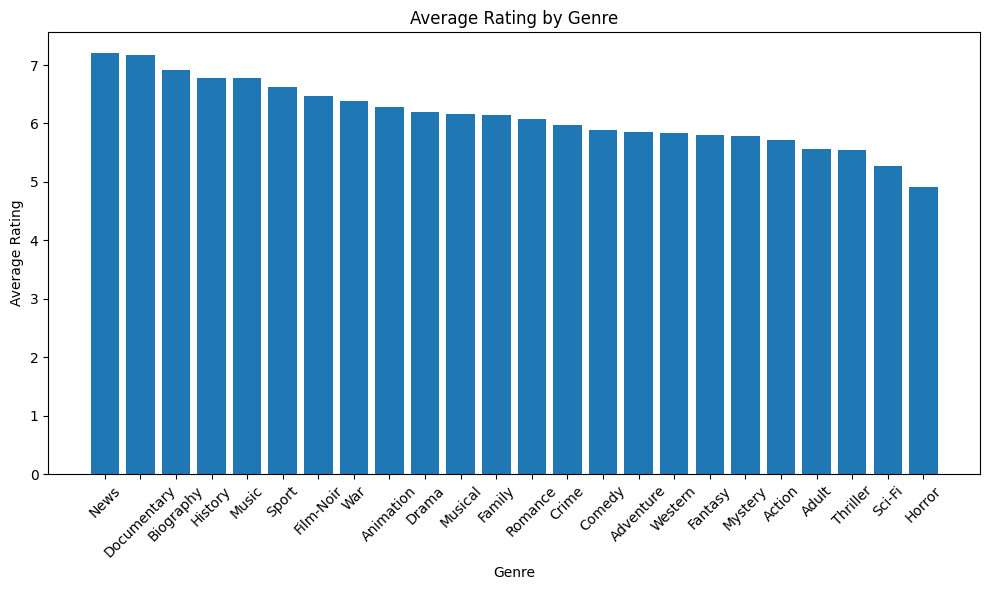

In [0]:

# Convert Spark DataFrame to Pandas

top_genres_pd = top_genres.toPandas()

plt.figure(figsize=(10,6))
plt.bar(
    top_genres_pd["genre"], 
    top_genres_pd["avg_rating"]
)

plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)  # Rotate labels to improve readability.
plt.tight_layout()
plt.show()


### Visualization 2 — Most Popular Genres by Total Votes

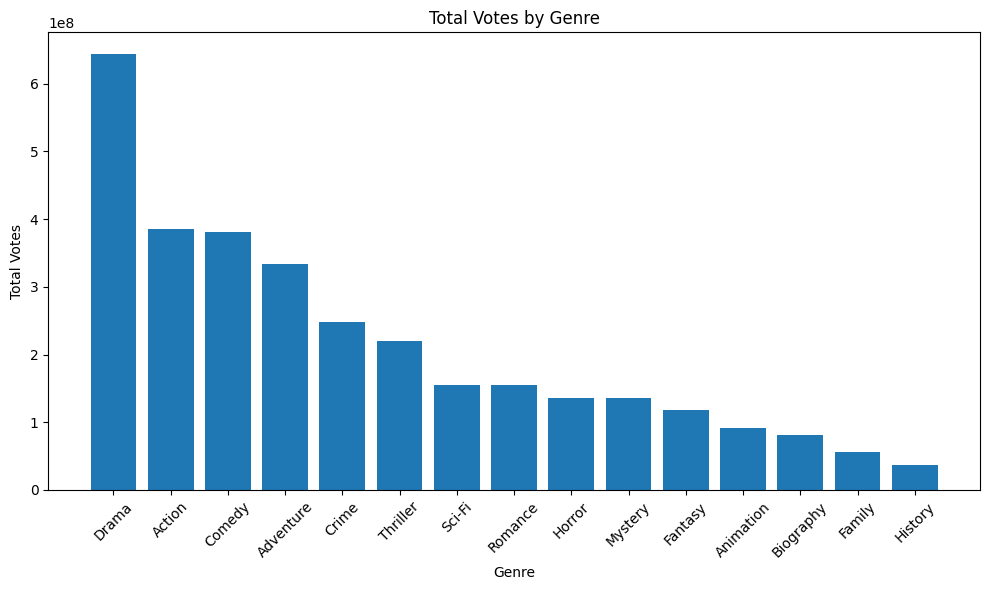

In [0]:

popular_genres_pd = popular_genres.toPandas()
# Limit to top 15 genres to keep the chart readable.

popular_genres_pd = popular_genres_pd.head(15)

plt.figure(figsize=(10,6))

plt.bar(
    popular_genres_pd["genre"],
    popular_genres_pd["total_votes"]
)

plt.title("Total Votes by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Votes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 3 — Movie Production Trends Over Time

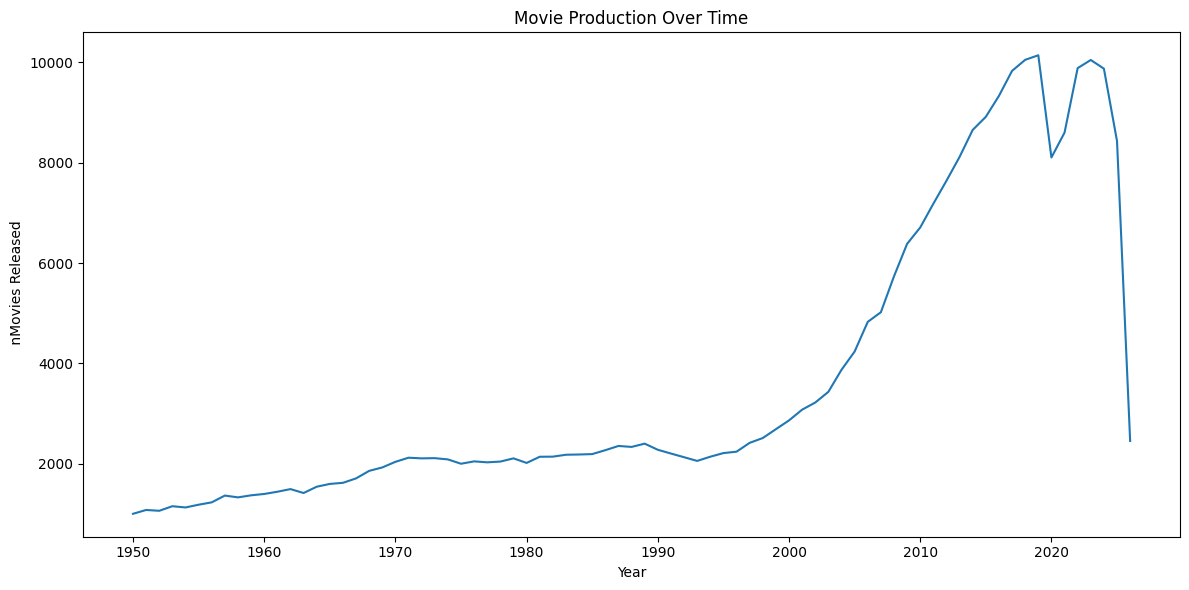

In [0]:
movies_per_year_pd = movies_per_year.toPandas()

plt.figure(figsize=(12,6))

plt.plot(
    movies_per_year_pd["startYear"],
    movies_per_year_pd["movies_released"]
)

plt.title("Movie Production Over Time")
plt.xlabel("Year")
plt.ylabel(" nMovies Released")

plt.tight_layout()
plt.show()

### Visualization 4 — Highest Rated Directors

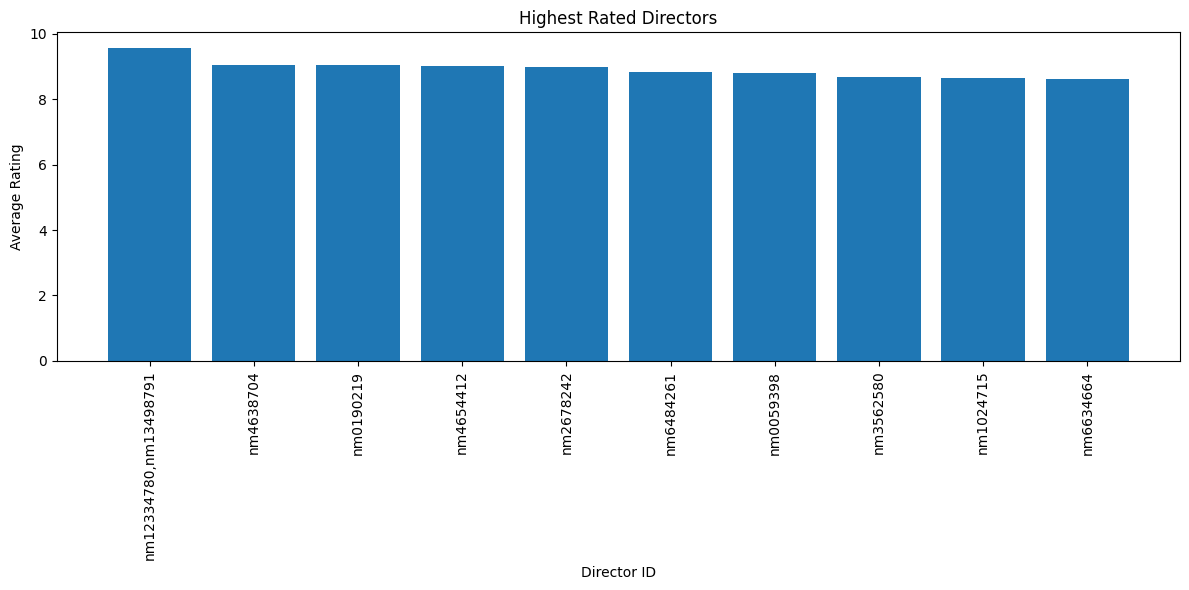

In [0]:
top_directors_pd = top_directors.toPandas().head(10) #limit to the top 10 directors for readability.

plt.figure(figsize=(12,6))

plt.bar(
    top_directors_pd["directors"],
    top_directors_pd["avg_rating"]
)

plt.title("Highest Rated Directors")
plt.xlabel("Director ID")
plt.ylabel("Average Rating")

plt.xticks(rotation=90) # Rotate labels because director IDs are long.
plt.tight_layout()
plt.show()

### Visualization 5 — Distribution of IMDb Ratings

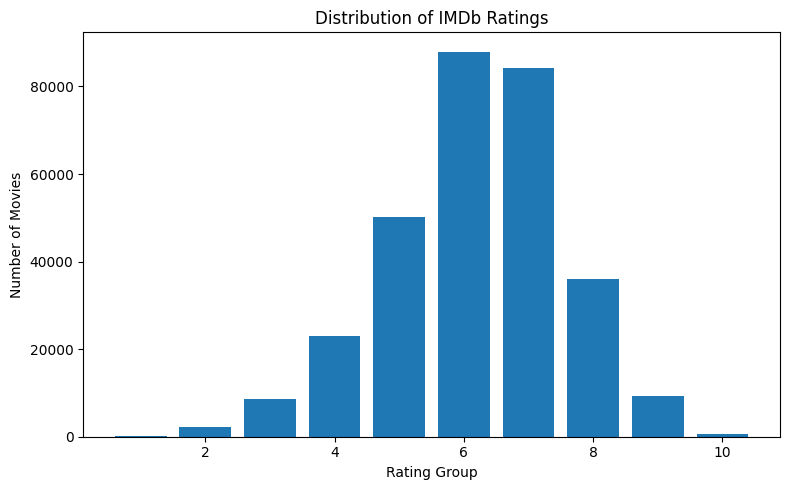

In [0]:
rating_distribution_pd = rating_distribution.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    rating_distribution_pd["rating_group"],
    rating_distribution_pd["movie_count"]
)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("Rating Group")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# 9. Key Findings
The analysis produced the following key findings:

- News, Documentary and Biography achieved the highest average IMDb ratings.
- Drama generated the highest audience engagement based on total votes.
- Movie production increased significantly after 2000 and peaked around 2019.
- Most movies received ratings between 5 and 7.
- A small subset of directors consistently achieved average ratings above 8.5 across multiple films, suggesting directorial consistency is associated with higher-rated output

These findings directly address the business question: genre, director, and production era are all characteristics associated with higher-rated films, and Apache Spark's integration capabilities made it possible to identify these patterns across over 300,000 movies.